What is micrograd?
Micrograd is basically an autograd engine. It's a scalar-valued autograd engine.

Autograd is short for automatic gradient. And really what it does is it implements backpropagation.

Back-propagation is this algorithm that allows you to efficiently evaluate the gradient of some kind of a loss function with respect to the weights of neural network. And what that allows us to do then is we can iteratively tune the weights of that neural network to minimize the loss function and therefore improve the accuracy of the network.

So backpropagation would be at the mathematical core of and modern deep neural network library, like Pytorch or JAX.

Neural networks are just a mathematical expression they take the input data as an input and they take the weights of a neural network as an input and it's a mathematical expression and your output is predictions of your neural net or the loss function.

## micrograd

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

Let's define a function, a scalar-valid function.

It just takes a single scalar x and returns a single scalar y.

In [3]:
def f(x):
    return 3*x**2 - 4*x + 5

In [4]:
f(3.0)

20.0

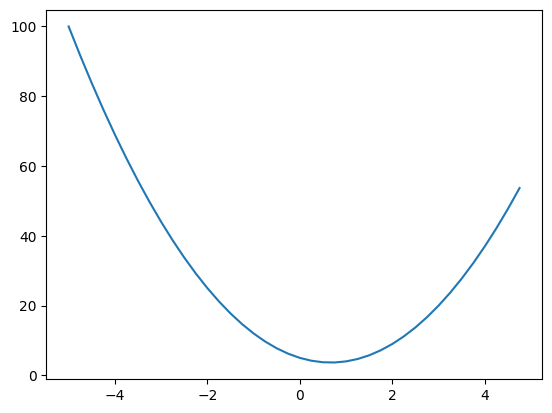

In [5]:
xs = np.arange(-5, 5, 0.25)
xs
ys = f(xs)
ys
plt.plot(xs, ys)

So now I'd like to think through what is the derivative of this function at any single input point x?

What is the derivative at different points x of this function?

No one in neural networks actually writes out the expression for the neural network net. It would be a massive expression. And so we're not going to take this kind of symbolic approach.

Instead, What I'd like to look at the definition of derivative and just make sure that we really understand what derivative is measuring, what it's telling you about the function.

The definition of derivative is the limit as 'h' goes to zero of 'f of x+h' minus 'f of x' over h.
So basically what it's saying is if you slightly bump up at some point x by a small number h, how does the function respond? With what sensitivity does it respond? What is the slope at that point? Does the function go up or go down? And by how much? And that's the slope of that function, the slope of that response at that point.

And so we basically evaluate the derivative here numerically by taking a very small h. And the definition would ask us to take h to zero.

In [6]:
h = 0.001
x = 3.0
f(x + h)

20.014003000000002

Do you expect 'f of x+h' to be slightly greater 20? or do you expect to be slightly lower than 20. 
If we slightly go positively, the function will respond positively. So you'd expect this to be slightly greater than 20.

And by how much is telling you the sort of the strength of that slope. The size of the slope.

In [7]:
h = 0.001
x = 3.0
(f(x + h) - f(x))/h

14.00300000000243

So this is just a numerical approximation of the slope, because we have to make age very small to converge to the exact amount.

In [8]:
h = 0.001
x = -3.0
(f(x + h) - f(x))/h

-21.996999999998934

In [9]:
h = 0.001
x = 2/3
(f(x + h) - f(x))/h

0.0029999999995311555

Let's get more complex case.

In [10]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


Now I'd like to look at the derivatives of d with respect to a, b, and c.

In [11]:
h = 0.0001

# input
a = 2.0
b = -3.0
c = 10.0

In [12]:
d1 = a*b + c
a += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [13]:
d1 = a*b + c
b += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)

d1 3.999699999999999
d2 3.99990001
slope 2.0001000000124947


In [14]:
d1 = a*b + c
c += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)

d1 3.99990001
d2 4.00000001
slope 0.9999999999976694


So, now we have some intuitive sense of what this derivative is telling you about the function.

And we'd like to move to neural networks.

Neural networks will be pretty massive expressions, mathematical expression.

So we need some data structures that maintain these expressions.

In [15]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f'Value(data={self.data})'
    # what the repr is doing is it's providing us a way to point out like a nice looking expression in Python

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out
    
    def __sub__(self, other): # self - other
        return self + (-other)

    def __radd__(self, other): # other + self
        return self + other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __rmul__(self, other): # other * self
        return self * other

    def __truediv__(self, other): # self / other
        return self * other**-1

    def __neg__(self): # -self
        return self * -1

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float power for now"
        out = Value(self.data**other, (self,), f'**{other}')
        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def backward(self):
        
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        topo

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

but now python doesn't know how to add two value object, so we have to tell it.

In [16]:
class Value:

    def __init__(self, data):
        self.data = data
    
    def __repr__(self):
        return f'Value(data={self.data})'

    def __add__(self, other):
        out = Value(self.data + other.data)
        return out

In [17]:
a = Value(2.0)
b = Value(-3.0)
a + b
# a.__add__(b)

Value(data=-1.0)

a.__add__(b) That's what will happen internally, so 'b' will be 'other' and 'self' will be 'a'.

So what we're going to return is a new value object, and it's just going to be wrapping the plus of their data, but remember now because data is the actual like python number so this operator here is just the typical floating point plus addition now, it's not an addition of value objects, and will return a new value.

Let's now implement multiply

In [18]:
class Value:

    def __init__(self, data):
        self.data = data
    
    def __repr__(self):
        return f'Value(data={self.data})'

    def __add__(self, other):
        out = Value(self.data + other.data)
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data)
        return out

In [19]:
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)
a*b
# a.__mul__(b)
a*b + c
# (a.__mul__(b)).__add__(c)

Value(data=4.0)

So now we are missing is the connected tissue of this expression.

We want to keep these expression graphs. So we need to know and keep pointers about what values produce what other values.

So here we are going to introduce a new variable, which we'll call 'children', and by default it will be an empty tuple.

And then we're going to keep a slightly different variable in the class, which we will call 'underscore prev', which will be the 'set of children'. 

In [20]:
class Value:

    def __init__(self, data, _children=()):
        self.data = data
        self._prev = set(_children)
        
    def __repr__(self):
        return f'Value(data={self.data})'

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other))
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other))
        return out

so now when we create a value like 'a = Value(2.0)' with a constructor, children will be empty and prep will be the empty set.

But when we are creating a value through addition or multiplication, we're going to feed it in the children of this value, which in this case is self and other.

In [21]:
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)
d = a*b + c
d
d._prev

{Value(data=-6.0), Value(data=10.0)}

So we know now the children of every single value, but we don't know what operation created this value.

So we need one more element here, let's call it 'underscore op'.

In [22]:
class Value:

    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        
    def __repr__(self):
        return f'Value(data={self.data})'

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

so now we not just have d._prev, we also have d._op

In [23]:
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)
d = a*b + c
d
d._op

'+'

And we know that d was produced by an addition of those two value.

So now we have the full mathematical expression, and we're building out this data structure, and we know exactly how each value came to be, by what expression, and from what other values.

Now, because these expressions are about to get quite a bit larger, we'd like a way to nicely visualize these expressions that we're building out.

In [24]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = '{ data %.4f }' % (n.data), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
        
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

Basically, what it does is it creates a new function, drawDot, that we can call on some root node. And then it's going to visualize it.

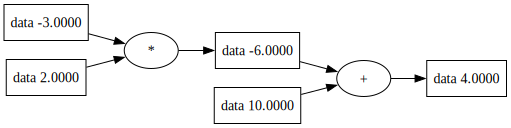

In [25]:
draw_dot(d)

So, let's create a special underscore label or let's just do label equals empty by default and save it in each node.

In [26]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
    def __repr__(self):
        return f'Value(data={self.data})'

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out


In [27]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
d

Value(data=4.0)

In [28]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = '{ %s | data %.4f }' % (n.label, n.data), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
        
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

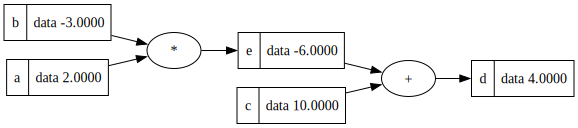

In [29]:
draw_dot(d)

In [30]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L

Value(data=-8.0)

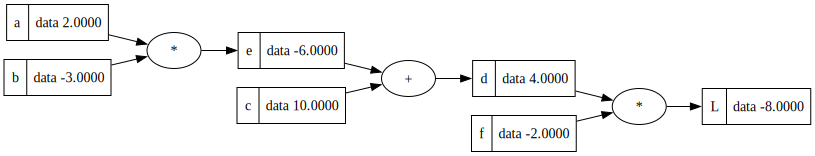

In [31]:
draw_dot(L)

So, let's recap what we've down so far.

We're able to build out mathematical expressions using only plus and times so far. They are scale value along the way. And we can do this forward pass and build out a mathematical expression.

And here is visualizing the forward pass.

Now, what we like to do next is to run backpropagation.

In backpropagation, we're going to start here at the end, and we're going to reverse and calculate the gradient along all these intermediate values.

What we're computing for every single value here, we're going to compute the derivative of that node with respect to L.

We are going to derive what is the derivative of L with respect to f, with respect to d, with respect to c, with respect to e, with respect to b, and with respect to a.

In neural network setting, you'd be very interested in the derivative of this loss function, L, respect to the weights of a neural network. And we need to know how those weights are impacting the loss function. We will be interested in the derivative of the output with respect to some of its leaf nodes and those leaf nodes will be the weights of the neural net, and the other leaf nodes will be the data itself but usually we will not want or use the derivative of the loss function with respect to data because the data is fixed, but the weights will be iterated on using the gradient information.

So next we are going to create a variable inside the value class that maintains the derivative of L respect to with respect to that value, and we will call this variable grad.

So there's a dot data and there's a self.grad and initially it will be zero.

And remember that zero is basically means no effect.

So at initialization, we're assuming that every value does not impact the output, because if the gradient is zero, that means that changing this variable is not changing the loss function.

In [32]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        # So by default, we assume that the gradient is zero
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
    def __repr__(self):
        return f'Value(data={self.data})'

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

In [33]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L

Value(data=-8.0)

So we're going to visualize it after data.

In [34]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = '{ %s | data %.4f | grad %.4f }' % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
        
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

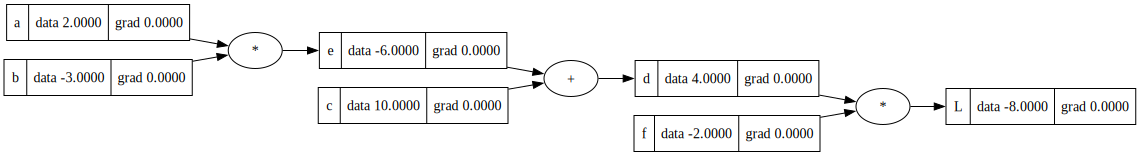

In [35]:
draw_dot(L)

And we are just about getting ready to calculate the backpropagation.

grad, is representing the derivative of the output, in this case L, with respect to this value.

So let's now fill in those gradients and actually do backpropagation manually.

So what is the derivative of L with respect to L? In other words, if I change L by a tiny amount h, how much does L change?

In [36]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        # So by default, we assume that the gradient is zero
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
    def __repr__(self):
        return f'Value(data={self.data})'

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

In [37]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L

Value(data=-8.0)

we have L = d * f, we want to know what is dL/dd = ? f

we go back to the definition of derivative, 
(f(x+h) - f(x)) / h, 
((d + h) * f - d * f) / h,
h * f / h,
f

and dL/df = d

In [38]:
def lol():

    h = 0.0001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0 , label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = (d * f); L.label = 'L'
    L2 = L.data + h

    print((L2 - L1)/h)
lol()
# L.grad = 1.0

0.9999999999976694


In [39]:
def lol():

    h = 0.0001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0 + h, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = (d * f); L.label = 'L'
    L2 = L.data

    print((L2 - L1)/h)
lol()
# a.grad = 6.0

6.000000000021544


In [40]:
def lol():

    h = 0.0001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0 + h, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = (d * f); L.label = 'L'
    L2 = L.data

    print((L2 - L1)/h)
lol()
# b.grad = -4.0

-4.000000000008441


In [41]:
def lol():

    h = 0.0001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0 + h, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = (d * f); L.label = 'L'
    L2 = L.data

    print((L2 - L1)/h)
lol()
# c.grad = -2.0

-1.9999999999953388


In [42]:
def lol():

    h = 0.0001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    e.data += h
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = (d * f); L.label = 'L'
    L2 = L.data

    print((L2 - L1)/h)
lol()
# e.grad = -2.0

-1.9999999999953388


In [43]:
def lol():

    h = 0.0001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    d.data += h
    f = Value(-2.0, label='f')
    L = (d * f); L.label = 'L'
    L2 = L.data

    print((L2 - L1)/h)
lol()
# d.grad = -2.0

-1.9999999999953388


In [44]:
def lol():

    h = 0.0001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0 , label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0 + h, label='f')
    L = (d * f); L.label = 'L'
    L2 = L.data

    print((L2 - L1)/h)
lol()
# f.grad = 4.0

3.9999999999995595


In [45]:
L.grad = 1.0
d.grad = -2.0
f.grad = 4.0
e.grad = -2.0
c.grad = -2.0
a.grad = 6.0
b.grad = -4.0

In [46]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = '{ %s | data %.4f | grad %.4f }' % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
        
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

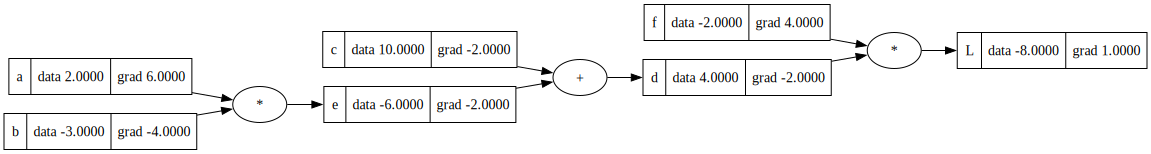

In [47]:
draw_dot(L)

We have the final output value all the way at the end of this graph. And we're now like a small node here. And this is a little plus node. 

L = d * f
d = e + c
e = a * b

local derivative

dL / dd = f = -2
dL / df = d = 4

---------------------------
This is a little plus node, and the little plus node doesn't know anything about the rest of the graph that it's embedded in. All it knows is that it did a plus. It took a 'c' and 'e', added them, and create 'd', and this plus node also knows the local influence of 'c' on 'd' or rather the derivative of 'd' with the respect to 'c', and it also knows the derivative of 'd' with respect to 'e', that's just a local derivative. What we want is 'dL/dc'. 

We know how 'd' impacts 'L' and how 'c' and 'e' impacts 'd'. And how do we put that information together to write dL/dc?
The chain rule in calculus. 
And the chain rule states that knowing the instantaneous rate of change of Z with respect to Y, and Y relative to X allows one to calculate the instantaneous rate of change of Z relative to X, as a product of those two rates of change. Simply the product of those two.

So literally what a plus node does, you can look at it that way, is it literally just routes the gradient because the plus nodes local derivative are just one. So in the chain rule, one times dL/dd is just dL/dd. And so that derivative just gets routed to both 'c' and 'e' in this case. 

dd / de = 1
dd / dc = 1

----------------------------

de / da = b = -3
de / db = a = 2

L.grad = dL / dL = 1
d.grad = dL / dd = f = -2
f.grad = dL / df = d = 4
e.grad = dL / de = (dL / dd) * (dd / de) = dL / dd = -2 * 1 = -2
c.grad = dL / dc = (dL / dd) * (dd / dc) = dL / dd = -2 * 1 = -2
a.grad = dL / da = (dL / dd) * (dd / de) * (de / da) = -2 * b = -2 * (-3) = 6
b.grad = dL / db = (dL / dd) * (dd / de) * (de / db) = -2 * a = -2 * 2 = -4

So this backpropagating single, which is carrying the information of like, what is the derivative of L with respect to all the intermediate node? 

We can imagine it almost like flowing backwards through the graph and a plus node will simply distribute the derivative to all the children nodes of it.

We've done is as you saw iterated through all the nodes one by one and locally applied the chain rule, we always know what is the derivative of L with respect to this little output and then we look at how this output was produced, this output was produced through some operation and we have the pointers to the children nodes of this through some operation and we have the pointers to the children nodes of this operation. And so in this little operation, we know what the local derivatives are and we just multiply them onto the derivative always. So we just go through and recursively multiply on the local derivatives. And that's what backpropagation is.

Let's see this power in action just very briefly.

We're going to nudge our inputs to try to make L go up.

And we want L to go up, that means we just have to go in the direction of the gradient.

In [48]:
# So should increase in the direction of gradient by like some small step amount.
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f

print(L.data)

-7.286496


So now I would like to do one more example of manual backpropagation using a bit more complex and useful example.

We are going to backpropagate through a neuron.

We want to eventually build up neural networks. And in the simplest case, these are multilayer perceptron. So this is a two-layer neural net.

we have some inputs 'xs', and then we have these synapses that have weights on them, so the 'ws' are weights, and then the synapse interacts with the input to this neuron multiplicatively, so what flows to the cell body of this neuron is 'w times x', but there's multiple inputs. 
So there's many 'ws times xs' flowing into the cell body. And the cell body then has also like bias. So the bias can make it a bit more trigger happy or a bit less trigger happy, regardless of the input. 
But basically we're taking all the w times x of all the inputs, adding this bias, and then we take it through an activation function. And this activation function is usually some kind of a squashing function, like a sigmoid or tanh or something like that.

So as an example, we're going to use the tanh in this example.

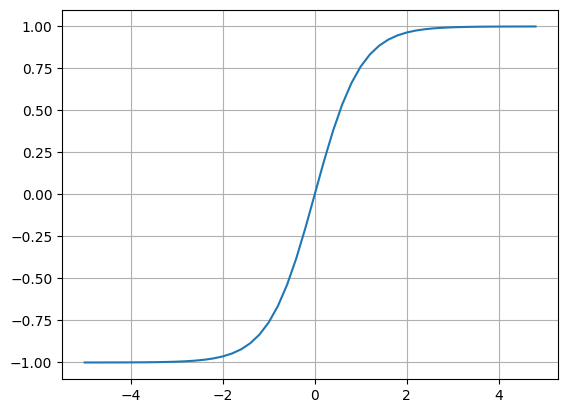

In [49]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid()

And you see that the inputs as they come in get squashed on the white coordinate here, so right at zero, we're going to get exactly zero and then as you go more positive in the input then you will see that the function will only go up to one and then plateau out. And so if you pass in very positive inputs, we're going to cap it smoothly at one. And at the negative side, we are going to cap it smoothly at negative one.

And what comes out of this neuron is just the activation function applied to the dot product of the weights and the inputs.

In [50]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f'Value(data={self.data})'
    # what the repr is doing is it's providing us a way to point out like a nice looking expression in Python

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

In [51]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = '{ %s | data %.4f | grad %.4f }' % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
        
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

In [52]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
# these weights, are the synaptic strengths for each inputs.
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.7, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

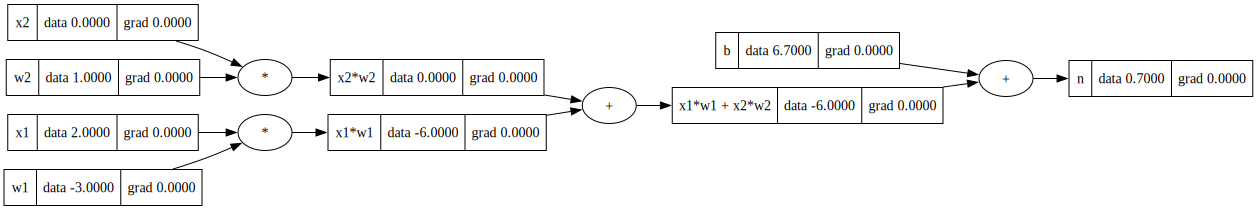

In [53]:
draw_dot(n)

So, we'd like to do here is to do the output, and call it 'o', is 'o.tanh()', but we haven't yet written the tanh.

Now, the reason that we need to implement another tanh function here is that tanh is a hyperbolic function, and we've only so far implemented a 'plus' and a 'times', and you can't make tanh out just 'plus' and 'times'. You also need exponentiation.

tanh(x) = sinh(x) / cosh(x) = (e^x - e^-x) / (e^x + e^-x) = (e^2x - 1) / (e^2x + 1)

And you see that there is exponentiation involved, which we have not implemented yet for our little value node here. So we're not going to be able to produce tanh yet, and we have to go back up and implement something like it.

And one option here is we could actually implement exponentiation and we could return the 'exp' of value instead of a 'tanh' of a value, because if we have 'exp' then we have everything else that we need, we know to 'add' and we know how to 'multiply'. So we'd able to create 'tanh' if we knew how to 'exp'.

But for the purposes of this example, I specifically wanted to show you that we don't necessarily need to have the most atomic pieces in this value object. We can actually create functions at arbitrary points of abstraction, they can be complicated functions but they can be also very simple functions like a plus and it's totally up to us the only thing that matters is that we know how to differentiate through any one function because we take some inputs and we make an output, the only thing that matters it can be arbitrarily complex function as long as you know how to create the local derivative, if you know the local derivative of how the inputs impacts the output then that's all you need.

So, we're going to cluster up all of this expression and we're not going to break it down to its atomic pieces. We're just going to directly implement tanh.

In [54]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f'Value(data={self.data})'
    # what the repr is doing is it's providing us a way to point out like a nice looking expression in Python

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        return out

As long as we know the derivative of tanh, then we'll be able to backpropagate through it.

In [55]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
# these weights, are the synaptic strengths for each inputs.
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.7, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

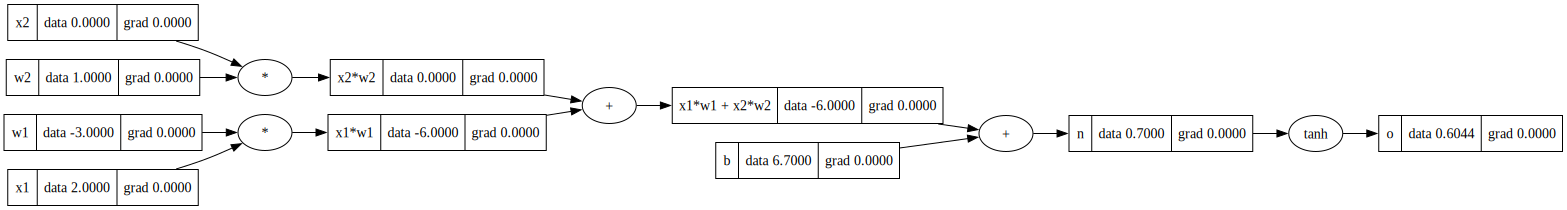

In [56]:
draw_dot(o)

Let's see this tanh in action.

Currently it's not squashing too much because the input to it is pretty low. So the bias was increased to, say, 8, then we'll see that what's flowing into the tanh now is 2 and tanh squashing it to 0.964, so we already hitting the tail of this tanh.

In [57]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
# these weights, are the synaptic strengths for each inputs.
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(8.0, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

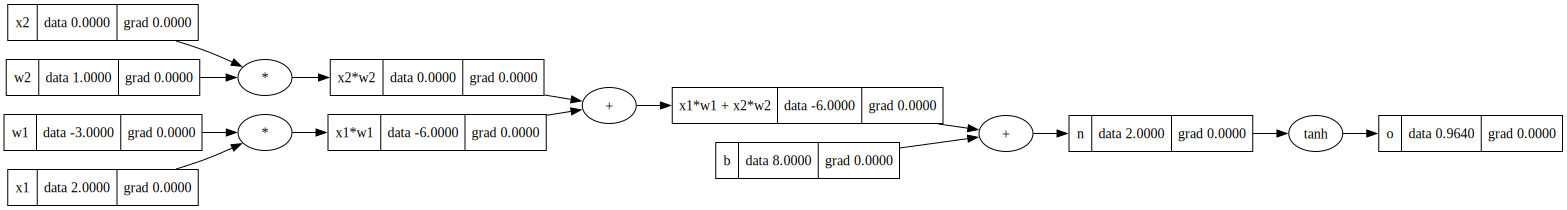

In [58]:
draw_dot(o)

So, I'm going to do something slightly strange. I'm going to change this bias to this number, 6.8813735870195432

And I'm going to do this for specific reasons because we're about to start bac propagation. And I want to make sure that our numbers come out nice. They're not like very crazy numbers. They're nice numbers that we can sort of understand in our hand.

In [59]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
# these weights, are the synaptic strengths for each inputs.
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

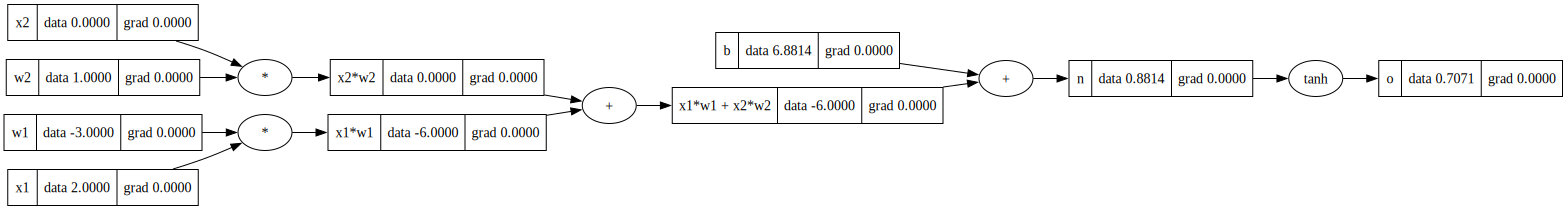

In [60]:
draw_dot(o)

So now we're going to do backpropagation, and we're going to fill in all the gradient.

So what is the derivative of 'o' with respect to all the inputs here? 

And in the neural network setting, what we really care about the most is the derivative of these neurons on the weights specifically, the 'w2' and 'w1', because those are the weights that we're going to be changing in part of the optimization.

And the other thing that we have to remember is here we have only a single neuron, but in the neural net you typically have many neurons and they're connected.

So this is only like one small neuron, a piece of a much bigger puzzle, and eventually there's a loss function that sort of measures the accuracy of the neural net, and we're back propagating with respect to that accuracy and trying to increase it. 

In [61]:
o.grad = 1.0
n.grad = 0.5
x1w1x2w2.grad = 0.5
b.grad = 0.5
x1w1.grad = 0.5
x2w2.grad = 0.5
x1.grad = -1.5
w1.grad = 1.0
x2.grad = 0.5
w2.grad = 0.0

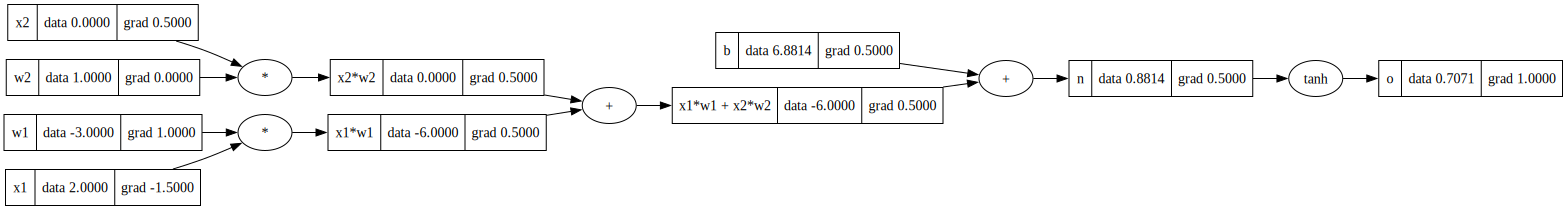

In [62]:
draw_dot(o)

So we're going to backpropagate through the tanh so to backpropagate through tanh, we need to know the local derivative of tanh, so if we have that'o' is 'tanh of n' then what 'do / dn'?

do / dn = ?

dtanh(x) / dx = 1 - tanh(x)^2 = sech(x)^2 = 1 / cosh(x)^2

o = tanh(n)

do / dn = 1 - tanh(n)^2 = 1 - o^2

In [63]:
o.data

0.7071067811865476

In [64]:
1 - o.data**2
# n.grad

0.4999999999999999

So now we're going to continue the backpropagation

A plus is just a distributor of gradient, so this gradient will simply flow to both of these equally. And that because the local derivative of this operation is one of every one of its nodes.

dn / d(x1 * w1 + x2 * w2) = 1.0
dn / db = 1.0

x1w1x2w2.grad = 0.5
b.grad = 0.5

x1w1.grad = 0.5
x2w2.grad = 0.5

Keep in mind again, what the derivative is telling us at every point in time along here. This is saying that if we want the output of this neuron to increase then the influence on these expressions is positive on the output. Both of them are positive contribution to the output. 

x1.grad = w1.data * x1w1.grad = (-3) * 0.5 = -1.5
w1.grad = x1.data * x1w1.grad = 2 * 0.5 = 1.0

x2.grad = w2.data * x2w2.grad = 1.0 * 0.5 = 0.5
w2.grad = x2.data * x2w2.grad = 0.0 * 0.5 = 0.0

Derivative always tells us the influence of this on the final output, if I wiggle w2, how is the output changing?
It's not changing, because we're multiplying by zero.

So, if we want this neurons output to increase, we know that what's necessary is that 'w2', we have no gradient, doesn't actually matter to this neuron right now. But this neuron, 'w1', should go up, this weight goes up, then this neuron's output would have gone up proportionally, because the gradient is one.

Doing backpropagation manually is obviously ridiculous. So we're now going to put an end to this suffering and we're going to see how we can implement the backpropagation, the backward pass a bit more automatically. We're not going to be doing all of it manually out here. It's now pretty obvious to us by example how these plus and times are backpropagation gradients.

So let's go up to the value object and we're going to start co-defying what we've seen in the examples below.

So, we're going to do this by storing a special self.backward, and underscore backward, and this will be a function which is going to do that little piece of chain rule at each little node that took inputs and produced output. We're going to store how we are going to chain to outputs gradient into the inputs gradients. 

So by default, this will be a function that doesn't do anything. And that would be sort of the case, for a leaf node, there's nothing to do. 

But when we creating these 'out' value, these 'out' values are an addition of self and other. And so we will want to set 'out's backward to be the function that propagates the gradient. And we're going to store it in a closure. 

Let's define what should happen when we call 'out's' grad.

We want the local derivative times the sort of global derivative which is the derivative of the final output of the expression with respect to out's data with the respect to out.

So the local derivative of self in an addition is 1.0

In [65]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f'Value(data={self.data})'
    # what the repr is doing is it's providing us a way to point out like a nice looking expression in Python

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad = 1.0 * out.grad
            other.grad = 1.0 * out.grad
        
        out._backward = _backward

        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad = other.data * out.grad
            other.grad = self.data * out.grad

        out._backward = _backward

        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad = (1 - t**2) * out.grad
        
        out._backward = _backward

        return out

And so we're going to redefine the expression, make sure that all the grads are zero, but now we don't have to do this manually anymore.

In [66]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
# these weights, are the synaptic strengths for each inputs.
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

out.grad is initialized to 0.0, so as the base case, we need to set both that grad to 1.0, to initialize to 1.0

In [67]:
o.grad = 1.0
o._backward()
n._backward()
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()

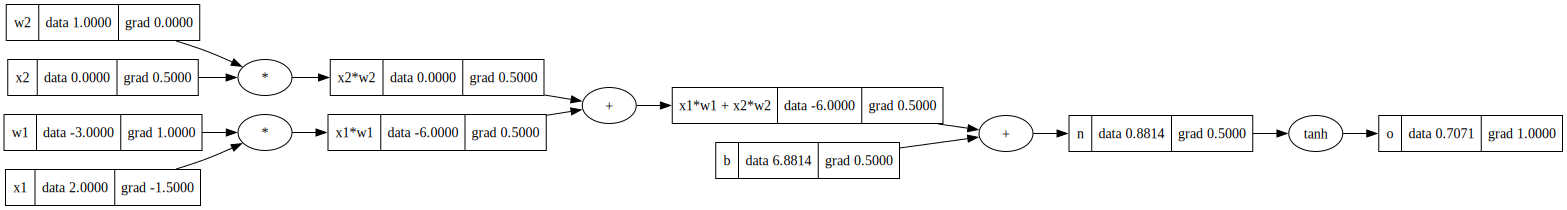

In [68]:
draw_dot(o)

So we've laid out a mathematical expression and now we're trying to go backwards through that expression, so going backwards through the expression just means that we never want to call a dot backward for any node before we've done sort of everything after it.

So we have to do everything after it before we're ever going to call '.backward()' on any one node. We have to get all of its full dependencies, everything that it depends on has to propagate to it before we can continue backpropagation.

So the ordering of graphs can be achieved using something called topological sort.

In [69]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
# these weights, are the synaptic strengths for each inputs.
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

In [70]:
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
topo

[Value(data=1.0),
 Value(data=0.0),
 Value(data=0.0),
 Value(data=-3.0),
 Value(data=2.0),
 Value(data=-6.0),
 Value(data=-6.0),
 Value(data=6.881373587019543),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

This is basically what builds a topological graph. We maintain a set of visited nodes, and then we are going through, starting at some root node, which for us is 'o'. That's where we want to start the topological sort.

And starting at 'o', we are go through all of its children, and we need to lay them out from left to right.

And really what we're doing now is we're just calling dot underscore backward on all of the node in a topological order.

In [71]:
o.grad = 1.0

topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
topo

for node in reversed(topo):
    node._backward()

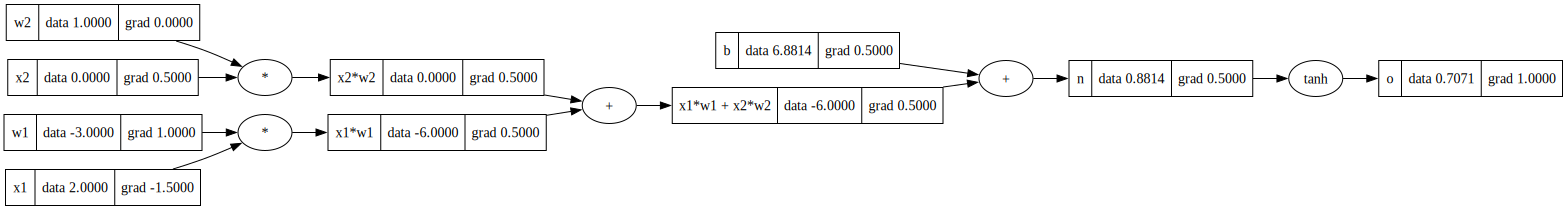

In [72]:
draw_dot(o)

In [73]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f'Value(data={self.data})'
    # what the repr is doing is it's providing us a way to point out like a nice looking expression in Python

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad = 1.0 * out.grad
            other.grad = 1.0 * out.grad
        
        out._backward = _backward

        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad = other.data * out.grad
            other.grad = self.data * out.grad

        out._backward = _backward

        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad = (1 - t**2) * out.grad
        
        out._backward = _backward

        return out

    def backward(self):
        
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        topo

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [74]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
# these weights, are the synaptic strengths for each inputs.
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

In [75]:
o.backward()

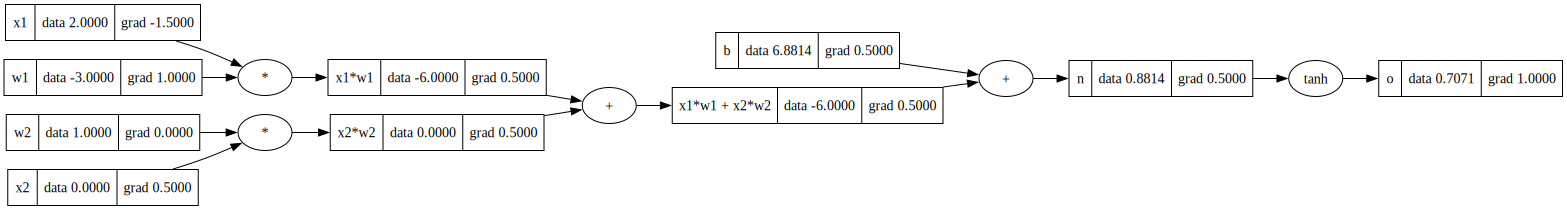

In [76]:
draw_dot(o)

We shouldn't be too happy with ourselves actually because we have a bad bug and we have not surfaced the bug because of some specific conditions that we have to think about right now.

Here the list to show the bug.

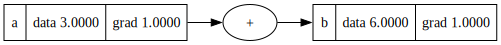

In [77]:
a = Value(3.0, label='a')
b = a + a; b.label = 'b'
b.backward()
draw_dot(b)

So what's going to happen is 'a' is 3, and then 'b' is 'a' plus 'a'. So there's two arrows on top of each other here. 

Then we can see that 'b', the forward pass works, is 6. But the gradient here is not actually correct, that we calculated automatically. 

And that's because 'b' is the result of the addition, then when we called backward what happened is self.grad was set to 1 and other.grad was set to 1, because we're doing 'a' plus 'a' self and other are actually the exact same object so we are overriding the gradient, we are setting it to 1 and then we are setting it again to 1, and that's why it says at 1, so that's a problem.

There's another way to see this in a little bit more complicated expression.

we call f.backward and these gradients if you check will be incorrect so fundamentally what's happening here again is we're going to see an issue anytime we use a variable more then once. 

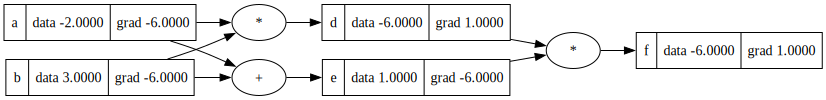

In [78]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b; d.label = 'd'
e = a + b; e.label = 'e'
f = d * e; f.label = 'f'

f.backward()

draw_dot(f)

The expression above, every variable is used exactly once, so we didn't see the issue.

But here, if the variable is used more than once, what's going to happen during backward pass?
We are backpropagating from 'f' to 'e' to 'd', so far so good, but now 'e' calls it backward, and it deposits its gradients to 'a' and 'b', but then we come back to 'd' and call backward, and it overwrites those gradient at 'a' and 'b'. So that's obviously a problem.

And the solution here, if you look at the multivariate case of the chain rule and the solution there is basically that we have to accumulate these gradient. And so instead of setting those gradients, we can simply do plus equals. We need to accumulate those gradients.

In [79]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f'Value(data={self.data})'
    # what the repr is doing is it's providing us a way to point out like a nice looking expression in Python

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        
        out._backward = _backward

        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward

        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        
        out._backward = _backward

        return out

    def backward(self):
        
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        topo

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

Remember because we are initializing them at zero, so they start at zero and then any contribution that flows backward will simply add.

Because a.grad started at zero, and when we call b.backward, we deposit one, and then we deposit one again, and now this is two, which is correct.

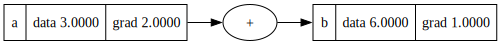

In [80]:
a = Value(3.0, label='a')
b = a + a; b.label = 'b'
b.backward()
draw_dot(b)

This will also work, and we'll get correct gradients, because when call e.backward, we will deposit the gradients for the branch, and then when we get to d.backward, it will deposit its own gradients, and then those gradients simply add on top of each other. And so we just accumulate those gradients, and that fixes the issue.

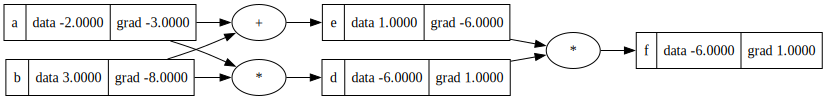

In [81]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b; d.label = 'd'
e = a + b; e.label = 'e'
f = d * e; f.label = 'f'

f.backward()

draw_dot(f)

Let's come back to this non-linearity here that we implemented the 'tanh'.

Now I told you that we could have broken down 'tanh' into its explicit atoms in terms of other expressions if we had the 'exp' function. So if you remember 'tanh' is defined like this 'tanh(x) = sinh(x) / cosh(x) = (e^x - e^-x) / (e^x + e^-x) = (e^2x - 1) / (e^2x + 1)', and we chose to develop 'tanh' as a single function and we can do that, because we know it's derivative and we can backpropagate through it. But we can also break down 'tanh' into and express it as a function of 'exp' and I would like to do that now because I want to prove to you that you get all the same results and all the same gradients but also because it forces us to implement a few more expressions.

Let's scroll up to the definition of value.

In [82]:
a = Value(2.0)
a + 1

AttributeError: 'int' object has no attribute 'data'

We can't do that because it says int object has no attribute data that's because 'a' plus 1 comes right here to add and then other is the integer 1, and then here python is trying to access 1.data and that's not a thing and that's because basically 1 is not a value object and we only have addition for value objects 

so as a matter of convenience so that we can create expressions like this and make them make sense we can simply do something like this. 

Basically, we let other alone if other is an instance of value. But if it's not an instance of value, we're going to assume that it's a number, like an integer or a float, and we're going to simply wrap it in the value. And then other will just become value of other, and then other will have a data attribute, and this should work.

In [ ]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f'Value(data={self.data})'
    # what the repr is doing is it's providing us a way to point out like a nice looking expression in Python

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        
        out._backward = _backward

        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward

        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        
        out._backward = _backward

        return out

    def backward(self):
        
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        topo

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [ ]:
a = Value(2.0)
a + 1

Value(data=3.0)

Now let's do the exact same thing for multiply because we can't do something like this.

In [ ]:
a = Value(2.0)
a * 2

AttributeError: 'int' object has no attribute 'data'

In [ ]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f'Value(data={self.data})'
    # what the repr is doing is it's providing us a way to point out like a nice looking expression in Python

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        
        out._backward = _backward

        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward

        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        
        out._backward = _backward

        return out

    def backward(self):
        
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        topo

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [ ]:
a = Value(2.0)
a * 2

Value(data=4.0)

Now here's a kind of unfortunate and not obvious part 'a' times '2' works, but '2' times 'a' is that gonna work?

In [ ]:
a = Value(2.0)
2 * a

TypeError: unsupported operand type(s) for *: 'int' and 'Value'

The reason it won't is because when you do 'a' times '2' Python will go a.__mul__(2), but '2' times 'a' is the same as 2.__mul__(a), and '2' can't multiply 'a', so it really confused about that.

So instead what happens is in Python the way this works is you are free to define something called the 'rmul', and 'rmul' is kind of like a fallback so if python can't do '2' times 'a', it will check if by any chance 'a' knows how to multiply '2' and that will be called into 'rmul'. Because python can't do '2' times 'a', it will check is there an 'rmul' in value and because there is it will now call that. And what we'll do here is we will swap the order of the operands.

So basically '2' times 'a' will redirect to our 'mul', and our 'mul' will basically call 'a * 2'. And that's how that will work.

In [ ]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f'Value(data={self.data})'
    # what the repr is doing is it's providing us a way to point out like a nice looking expression in Python

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        
        out._backward = _backward

        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward

        return out

    def __rmul__(self, other): # other * self
        return self * other

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        
        out._backward = _backward

        return out

    def backward(self):
        
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        topo

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [ ]:
a = Value(2.0)
2 * a
# a.__mul__(2)

Value(data=4.0)

Looking at the other elements that we still need, we need to know how to exponentiate and how to divide.

So, let's first do the the exponentiation part.

We are going to introduce a single function 'exp' here, and 'exp' is going to mirror tanh, in the sense that it's a single function that transforms a single scalar value and outputs a single scalar value. So, we pop out the Python number, we use math.exp to exponentiate it, create a value object. The tricky part is how do you backpropagate through 'e to the x'.

In [ ]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f'Value(data={self.data})'
    # what the repr is doing is it's providing us a way to point out like a nice looking expression in Python

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        
        out._backward = _backward

        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward

        return out

    def __rmul__(self, other): # other * self
        return self * other

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        
        out._backward = _backward

        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad

        out._backward = _backward
        
        return out

    def backward(self):
        
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        topo

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [ ]:
a = Value(2.0)
a.exp()

Value(data=7.38905609893065)

And the last thing we'd like to do is we'd like to be able to divide.

Now I actually will implement something slightly more powerful than division, because the division is just a special case of something a bit more powerful.

So in particular, just by rearranging, if we would have some kind of a 'b equals value of 4.0' here, we'd like to basically be able to do 'a divide b', and we'd like to this to give us 0.5.

If we have 'a' divide 'b', that's actually the same as 'a' multiply '1 over b # 1/b', and as the same as 'a' multiply 'b to the power of negative 1 # b^-1'.

In [ ]:
a = Value(2.0)
b = Value(4.0)
a / b
a * (1/b)
a * (b**-1)

TypeError: unsupported operand type(s) for /: 'Value' and 'Value'

In [ ]:
a = Value(2.0)
b = Value(4.0)
a - b

TypeError: unsupported operand type(s) for -: 'Value' and 'Value'

So what I'd like to do instead is I'd like to implement the operation for 'x to the k for some constant k'. So it's an integer or a float, and we would like to be able to differentiate this.

So basically we can redefine division.

And now value raised to the power of negative 1, we have to define that. We need to implement the power function.

And we also have to know how to subtract. So right now 'a minus b' will not work. Basically this is the subtraction, and the way we're going to implement subtraction is we're going to implement it by addition of a negation and then to implement negation, we're going to multiply by negative 1.

So just again using the stuff we've already built and just expressing it in terms of what we have.

In [ ]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f'Value(data={self.data})'
    # what the repr is doing is it's providing us a way to point out like a nice looking expression in Python

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        
        out._backward = _backward

        return out
    
    def __sub__(self, other): # self - other
        return self + (-other)

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward

        return out

    def __rmul__(self, other): # other * self
        return self * other

    def __truediv__(self, other): # self / other
        return self * other**-1

    def __neg__(self): # -self
        return self * -1

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float power for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward

        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        
        out._backward = _backward

        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad

        out._backward = _backward
        
        return out

    def backward(self):
        
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        topo

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [ ]:
a = Value(2.0)
b = Value(4.0)
a / b

Value(data=0.5)

In [ ]:
a = Value(2.0)
b = Value(4.0)
a - b

Value(data=-2.0)

Let's go again for this neuron, so I would like to do is I'd like to break up this tanh, and we will change how we define o.

tanh(x) = sinh(x) / cosh(x) = (e^x - e^-x) / (e^x + e^-x) = (e^2x - 1) / (e^2x + 1)

So we need 'e to the 2x minus 1' over 'e to the 2x plus 1', 'e to the 2x' we need to take '2 times n' and we need to exponentiate it. And because we're using it twice, let's create an intermediate variable 'e'. And define 'o' as 'e minus 1' over 'e plus 1'

In [6]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = '{ %s | data %.4f | grad %.4f }' % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
        
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

In [ ]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
# these weights, are the synaptic strengths for each inputs.
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.backward()

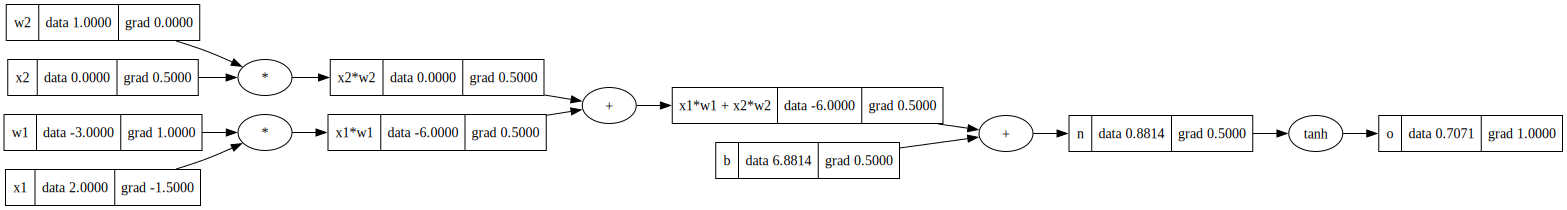

In [ ]:
draw_dot(o)

In [ ]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
# these weights, are the synaptic strengths for each inputs.
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
#----
e = (2*n).exp()
o = (e - 1) / (e + 1)
#----
o.label = 'o'
o.backward()

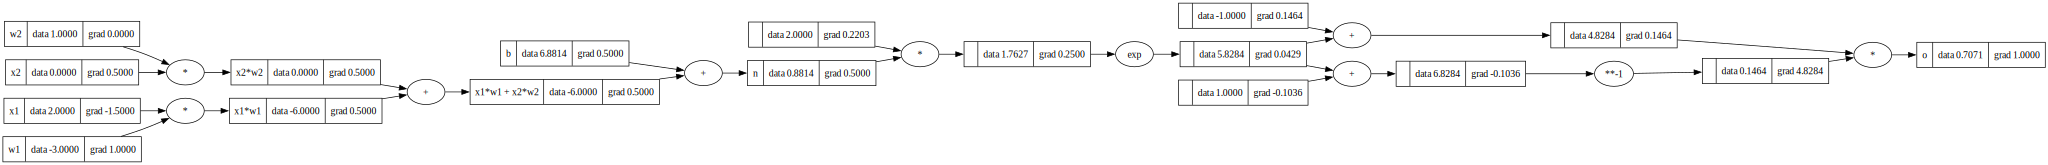

In [ ]:
draw_dot(o)

All the matter, we have some kind of inputs and some kind of an output, and this output is a function of the inputs in some way. And as long as you can do forward pass and the backward pass of that little operation, it doesn't matter what that operation is and how composite it is. If you can write the local gradients, you can chain the gradient and you can continue backpropagation. So the design of what those functions are is completely up to you.

So now I would like to show you how you can do the exact same thing, but using a modern deep neural network library, like for example, Pytorch, which I've roughly modeled micrograd by. And so Pytorch is something you would use in production. And I would show you how you can do the exact same thing, but in Pytorch API.

# Neural Network

Micrograd is a scalar-valued engine, so we only have scalar values like 2.0.

But in Pytorch, everything is based around tensors.

Tensors are just n-dimensional arrays of scalars.

I just need a scalar-valued tensor, a tensor with just a single element.

In [4]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import torch
import random

In [ ]:
torch.Tensor([[1, 2, 3], [4, 5, 6]])
torch.Tensor([[1, 2, 3], [4, 5, 6]]).shape

torch.Size([2, 3])

This tensor, is a 2 by 3 array of scalars in a single compact representation.

So this is actually what you would work with in the actual libraries.

In [ ]:
torch.Tensor([2.0])
torch.Tensor([2.0]).dtype
torch.Tensor([2.0]).double().dtype

torch.float64

I'm casting it to be double because Python is by default using double precision for its floating point numbers. So I'd like everything to be identical

By default, the data type of these tensors will be float32. So it only use single precision float.

The next thing I have to do is, because these are leaf nodes, by default Pytorch assumes that they do not require gradients. So I need to explicitly say that all of these nodes require gradients. By default, these are set to false, by the way, because of efficiency reasons, you would not want gradients for leaf nodes, like the inputs to the network. And this is just trying to be efficient in the most common cases.

So, once we've defined all of our values in Pytorch land, we can perform arithmetic just like we can here in micrograd land. And when we get back as a tensor again, and we can just like in micrograd, it's got a data attribute and it's got grad attributes. So these tensor objects, just like in micrograd have a '.data' and a '.grad'. And the only difference here is that we need to call a '.item' because otherwise Pytorch '.item' basically takes a single tensor of one element and it just returns that element stripping out the tensor.

In [84]:
x1 = torch.Tensor([2.0]).double()               ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()               ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()              ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()               ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double() ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item()) # o.item() and o.data.item() will produce the same result here in Pytorch
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


So basically torch can do what we did in micrograd as a special case when your tensors all single element tensors. But the big deal with Pytorch is that everything is significantly more efficient because we are working with these tensor objects and we can do lots of operations in parallel on all of those tensors.

But otherwise, what we've built very much agrees with the API of Pytorch.

So now we have some machinery to build out pretty complicated mathematical expressions, we can also start building out neural nets.

As I mentioned, neural nets are just a specific class of mathematical expressions.

So we're going to start building out a neural net piece by piece, and eventually will build out two-layer, multi-layer perceptron.

Let's start with a single individual neuron.

In [5]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f'Value(data={self.data})'
    # what the repr is doing is it's providing us a way to point out like a nice looking expression in Python

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        
        out._backward = _backward

        return out
    
    def __sub__(self, other): # self - other
        return self + (-other)

    def __radd__(self, other): # other + self  # right
        return self + other
    # 当有 3 + Value(2)
    # Python尝试顺序大致是
    # int.__add__(3, Value(2))    # 左边先试
    # 不行后再试
    # Value(2).__radd__(3)        # 右边接手
    # 你的 __radd__ 返回：
    # Value(2) + 3
    # 又会触发
    # Value(2).__add__(3)
    # 可以理解为Python的运算是分顺序的
    # 左边.__add__(右边)，右边.__radd__(左边) 可以看出调用的运算符不一样

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward

        return out

    def __rmul__(self, other): # other * self
        return self * other

    def __truediv__(self, other): # self / other
        return self * other**-1

    def __neg__(self): # -self
        return self * -1

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float power for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward

        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        
        out._backward = _backward

        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad

        out._backward = _backward
        
        return out

    def backward(self):
        
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        topo

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [7]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = '{ %s | data %.4f | grad %.4f }' % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
        
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

In [86]:
class Neuron:
    def __init__(self, nin): # nin is the number of inputs for this neuron.
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        # what we want to do here is w * x + b
        # w * x here is a dot product
        return 0.0

the way __call__ works now is, we an have a x = [2.0, 3.0]. Then we can initialize a neuron that is two-dimensional because x are two numbers.

And we can feed those two numbers into that neuron to get an output.

In [87]:
x = [2.0, 3.0]
n = Neuron(2) # nin = 2
n(x)
# Neuron.__call__(n, x)
# n.__call__(x)

0.0

x = [2.0, 3.0]
n = Neuron(2)
n(x)

nin = 2

执行流程：


先执行：
x = [2.0, 3.0] 
这里就是创建了一个普通 Python 列表
x[0] = 2.0
x[1] = 3.0


再执行：
n = Neuron(2)
这一步会调用类里的 __init__：
class Neuron:
    def __init__(self, 2):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(2)]
        self.b = Value(random.uniform(-1, 1))

n.w = [Value(从 (-1,1) 的均匀分布中随机抽取的数), Value(从 (-1,1) 的均匀分布中随机抽取的数)]
n.b = Value(从 (-1,1) 的均匀分布中随机抽取的数)

------------

self.w = [Value(random.uniform(-1, 1)) for _ in range(2)]
等价于
self.w = []
for _ in range(2):
    num = random.uniform(-1, 1)
    v = Value(num)
    self.w.append(v)
Value(random.uniform(-1, 1)) 是表达式
self.w = [Value(random.uniform(-1, 1)), Value(random.uniform(-1, 1))]

range(2)    表示一个序列，里面依次产生：0, 1

a = ['x', 'y']
for i in range(2):
    print(a[i])
这里：
第一次 i = 0，访问 a[0]
第二次 i = 1，访问 a[1]
所以：
range(2) 本身给的是 值 0 和 1
这些值有时候可以拿来表示列表里的“位置/索引”

for _ in range(nin)    这个变量我根本不关心，我只是想循环这么多次。
for _ in range(2)
先从 range(2) 里拿一个值
把这个值赋给变量 i
再执行下面缩进的代码
然后再拿下一个值，重复这个过程
for 的意思是：    把 range(nin) 里面的值，一个一个拿出来，每拿出一个，就执行一次下面的代码。

------------


最后执行：
n(x)
等价于
Neuron.__call__(n, x)
或
n.__call__(x)

n(x)
这只是把 外面的变量值 传进去。
外面的变量名字叫 x

若
def __call__(self, inputs):
    return  inputs

n(x)

n(x) 把外面的 变量值 传进函数以后，函数内部把它接到 inputs 这个参数上

则
x = [2.0, 3.0]
n = Neuron(2)
n(x)

只是把 外部变量x = [2.0, 3.0] 传进了 def __call__(self, x): 的 内部变量x 中

In [88]:
range(2)

range(0, 2)

In [89]:
for _ in range(2):
    print("hello")
# 等价于
print("hello")
print("hello")

hello
hello
hello
hello


In [90]:
w = [Value(random.uniform(-1, 1)) for _ in range(2)]
w

[Value(data=0.44106233068518486), Value(data=-0.2400132412530258)]

Now we'd like to actually do the forward pass of this neuron instead.

So what we're going to here first is we need to basically multiply all of the elements of w with all the elements of x pairwise. We need to multiply them.

So the first thing we are going to do is 'zip' up 'self.w' and 'x'.

In Python, 'zip' takes two iterators and it creates a new iterator that iterates over the tuples of their corresponding entries.

In [91]:
class Neuron:
    def __init__(self, nin): # nin is the number of inputs for this neuron.
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        # what we want to do here is w * x + b
        # w * x here is a dot product
        print(list(zip(self.w, x)))
        return 0.0

In [92]:
x = [2.0, 3.0]
n = Neuron(2)
n(x)

[(Value(data=-0.8780439826303976), 2.0), (Value(data=-0.7196396630550494), 3.0)]


0.0

So we see that this w are paired up with this x.

And now we want to do is, for wi, xi in zip(self.w, x), we want to wi times xi, and then we want to sum all of that together to come up with an activation, and add also self.b on top. So that's the raw activation.

And then we need to pass that through a null linearity. So what we're going to be returning is act.tanh.

In [93]:
class Neuron:
    def __init__(self, nin): # nin is the number of inputs for this neuron.
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        # what we want to do here is w * x + b
        # w * x here is a dot product
        act = sum(wi*xi for wi, xi in zip(self.w, x)) + self.b
        out = act.tanh()
        return out

In [94]:
x = [2.0, 3.0]
n = Neuron(2)
n(x)

Value(data=0.7467755636272506)

And we get different output from a neuron each time because we are initializing different weights and bias.

And then to be a bit more efficient here, actually, sum, by the way, takes a second optional parameter, which is the start. And by default, the start is zero. So the element of this sum will be add on top of zero to begin with. But actually we can just start wih self.b.

And then the generator expression here must be parenthesized in Python.

In [ ]:
class Neuron:
    def __init__(self, nin): # nin is the number of inputs for this neuron.
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        # what we want to do here is w * x + b
        # w * x here is a dot product
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

In [ ]:
x = [2.0, 3.0]
n = Neuron(2)
n(x)

Value(data=0.9934781261706199)

So, now we can forward a single neuron.

Next up, we are going to define a layer of neurons.

We see that these MLPs, each layer, has actually a number of neurons, and they're not connected to each other, but all of them are fully connected to the input.

So what is a layer of neurons? It just a set of neurons evaluated independently.

Layer is just a list of neurons.

And then how many neuron do we have? we take that as an input argument here, 'nout', how many neurons do you want in this layer, number of outputs in this layer.

So we just initialize completely independent neurons with this given dimensionality. And we call on it, we just independently evaluate them.

In [ ]:
class Neuron:
    def __init__(self, nin): # nin is the number of inputs for this neuron.
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        # what we want to do here is w * x + b
        # w * x here is a dot product
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

class Layer: # just a list of neurons
    def __init__(self, nin, nout): # nout is the number of neuron or output in this layer
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs

So now instead of a neuron, we can make a layer of neurons. They are two-dimensional neurons, and let's have three of them.

In [ ]:
x = [2.0, 3.0]
n = Layer(2, 3)
n(x)

[Value(data=-0.933250474500289),
 Value(data=-0.9839381178790357),
 Value(data=0.9971010823551948)]

Now we can see that we have three of independent evaluations of three different neurons.

Finally, let's complete this picture and define entire multi-layered perceptron, MLP.

And as we can see here in an MLP, these layers just feed into each other sequentially.

In [95]:
class Neuron:
    def __init__(self, nin): # nin is the number of inputs for this neuron.
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        # what we want to do here is w * x + b
        # w * x here is a dot product
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

class Layer: # just a list of neurons
    def __init__(self, nin, nout): # nout is the number of neuron or output in this layer
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

So, MLP is very similar. We are taking the number of inputs as before, but now instead of taking a single nout which is number of neurons in a single layer, we're going to take a list of nout, and this list defines the size of all the layers that we want in our MLP.

So here we just put them all together and then iterate over consecutive pairs of these sizes and create layer objects for them.

And then in the call function, we are just calling them sequentially.

So we want three input neurons and then two layers of four and an output unit.

In [96]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

[Value(data=0.37891420312417934)]

This is the forward pass of an MLP.

To make this a little bit nicer you see how we have just a single element, but it's wrapper in a list because layer always returns list circle, for convenience, return outs at zero if len outs is exactly a single element else return fullest, and this will allow us to just get a single value out at the last layer that only has a single neuron and finally we should able to draw dot of n of x, and as you might imagine these expressions are now getting relatively involved, so this is an entire MLP that we're defining now.



In [115]:
class Neuron:
    def __init__(self, nin): # nin is the number of inputs for this neuron.
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        # what we want to do here is w * x + b
        # w * x here is a dot product
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

class Layer: # just a list of neurons
    def __init__(self, nin, nout): # nout is the number of neuron or output in this layer
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

In [116]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=-0.4918831042628433)

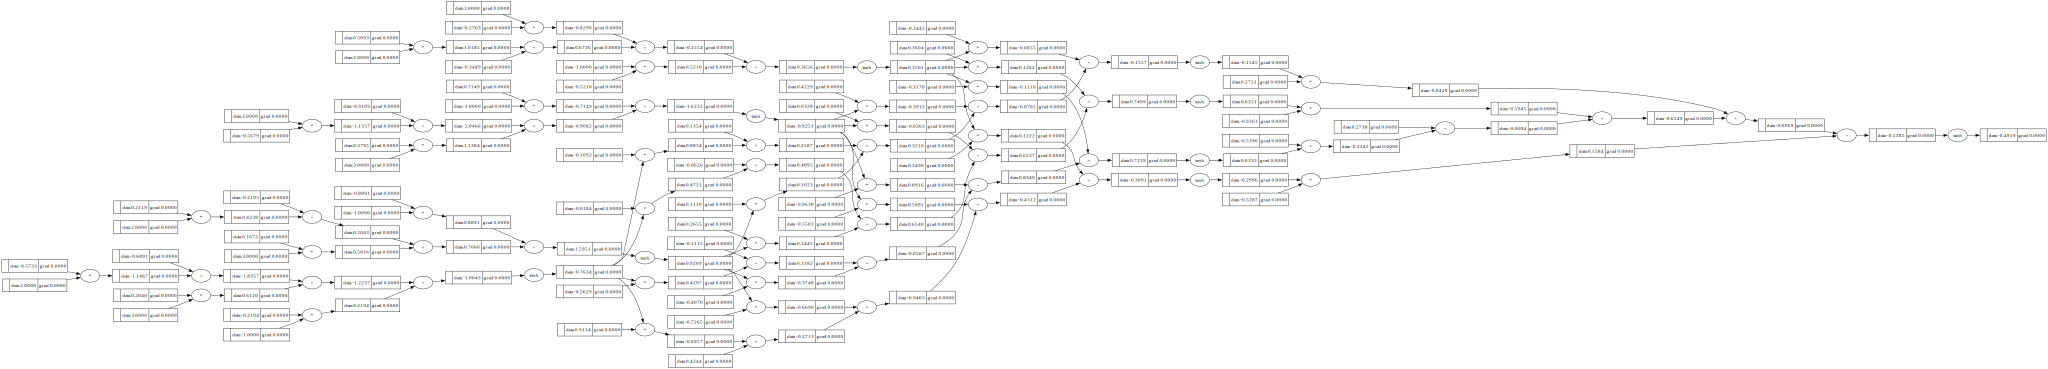

In [117]:
draw_dot(n(x))

So let's create ourselves a very simply example data set here.

So we have four possible inputs into the neural net. And we have four desire target. So we like the neural net to assign or output 1.0 when it's fed '[2.0, 3.0, -1.0]' this example, negative one when it's fed '[3.0, -1.0, 0.5] [0.5, 1.0, 1.0]' these examples, and one when it's fed '[1.0, 1.0, -1.0]' this example. 

So it's a very simple binary classifier neural net basically that we would like that here.

Now let's think what the neural net currently thinks about these four examples.

In [ ]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desire targets
ypred = [n(x) for x in xs]
ypred

[Value(data=-0.4918831042628433),
 Value(data=-0.8105874981976161),
 Value(data=-0.03144970163567499),
 Value(data=-0.5477926785680916)]

So these are the outputs of the neural net on those four examples.

The first one is 0.796, but we like to be 1, so we should push this one higher.
This one says 0.744, and we want this to be negative 1.
This is 0.606, and we want it to be negative 1.
And this one is 0.707, we want it to be 1.

So how do we make the neural net, and how do we tune the weights to better predict the desired targets?
And the trick used in deep learning to achieve this is to calculate a single number that somehow measures the total performance of your neural net. And we call the single number the loss.

So the loss, first, is a single number that we're going to define that basically measures how well the neural net is performing.

Right now we have the intuitive sense that it's not performing very well because we're not very much close to this. So the loss will be high and we'll want to minimize the loss.

So in particular, in this case, what we're going to do is we're going to implement the mean squared error loss. So what this is doing is we're going to iterate for y ground truth and y output in zip of ys and ypred.

So we are going to pair up the ground truths with the predictions and the zip iterates over tuples of them. And for each y ground truth and y output, we're going to subtract them and square them.

So let's first see what these losses are.

In [119]:
[(yout - ygt)**2 for ygt, yout in zip(ys, ypred)]

[Value(data=2.225715196784938),
 Value(data=0.03587709583903808),
 Value(data=0.9380896804616231),
 Value(data=2.3956621758289876)]

So basically, for each one of the four, we are taking the prediction and the ground truth, we are subtracting them and squaring them.

So, because '0.796' this one is so close to its target, subtracting them gives a very small number.

So you see that the expression is arranged so that you only get zero exactly when yout is equal to y ground truth. When those two are equal, so your prediction is exactly the target, you are going to get zero. And if you prediction is not your target, you are going to get some other number. And the more off we are, the greater the loss will be. So we don't want high loss, we want low loss.

So the final loss here will be just the sum of all of these numbers.

In [ ]:
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=5.595344148914586)

So now we want the loss would be low, because if loss low, then every one of the predictions is equal to its target.

So the loss, the lowest it can be zero, and the greater it is, the worse off the neural net is predicting.

So now, if we do the loss.backward

In [121]:
loss.backward()

In [122]:
n.layers[0].neurons[0].w[0].grad

-0.09749629437377863

we can look at n.layers.neuron at, like the first layers[0].neuron[0], because remember that MLP has the layers, which is a list, and each layer has neurons, which is a list, and that gives us an individual neuron, and then it's got some weights. And so we can, for example, look at the weights at zero, that's a value, but now this value also has a grad because of the backward pass.

And we see that because this gradient here on this particular weight of this particular neuron of this particular layer is negative, we see that its influence on the loss is also negative. So slightly increasing this particular weight of this neuron of this layer would make the loss go down. And we actually have this information for every single one of our neurons and all of their parameters.

Actually, it's worth looking at also the draw_dot of loss. So previously we looked at the draw_dot of a single neuron forward pass, and that was already a large expression. But what is the loss expression? We actually forwarded every one of those four examples, and then we have the loss on top of them with the mean squared error.

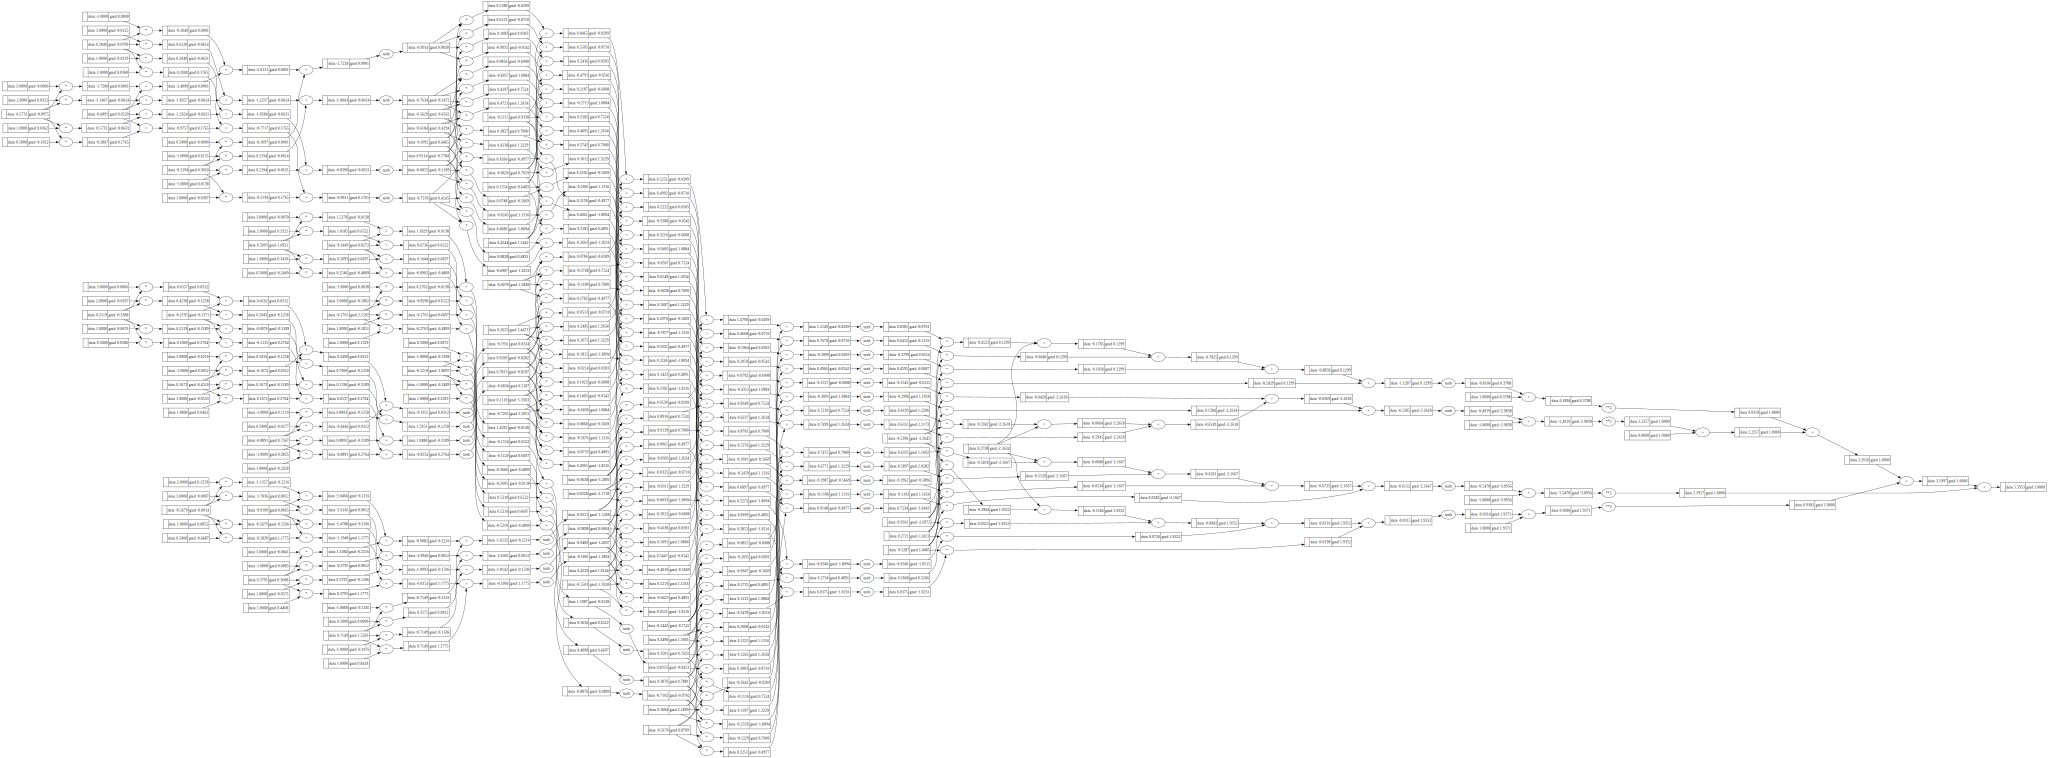

In [123]:
draw_dot(loss)

It's excessive because it has four forward passes of a neural net for every one of the examples, and then it has the loss on top, and it ends with the value of the loss, which is 5.5953, and this loss will now back propagate through all the forward passes all the way through just every single intermediate value of the neural net, all the way back to the parameters of the weights which are the input ,so these weight parameters 'self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]' are inputs to this neural net and these numbers 'xs = [[2.0, 3.0, -1.0]', are inputs to the neural net. So they all have gradients as well. The thing is these gradients on the 
              [3.0, -1.0, 0.5],
              [0.5, 1.0, 1.0],
              [1.0, 1.0, -1.0],]
input data are not that useful to us. And that's because the input data seems to be not changeable. It's given to the problem. So it's a fixed input. We're not going to be changing it or messing with it, even though we do have gradients for it. But some of these gradients here will be for the neural network parameters, the ws and the bs, and those we want to change.

So now we are going to want some convenience codes to gather up all of the parameters of neural net so that we can operate on all of them simultaneously. And every one of them, we will nudge a tiny amount based on the gradient information.

So let's collect the parameters of the neural net all in one array.

So it will just return a list, list plus list. 

So that's parameter's of neuron, and I'm calling it this way because also Pytorch has parameters on every single NN module. And it does exactly what we're doing here. It just returns the parameter tensors. For us is the parameter scalar.

So Layer is also has a module, so it will have parameters(self), and basically what we want to do is, 'params = []', and 'for neuron in self.neurons:', we want to get 'neuron.parameters()' and we want to params.extend(neuron.parameters())'.

So this is way too much code, actually there's a way to simplify this, which is return 'p for neuron in self.neurons for p in neuron.parameters().' In Python you can sort of nest them like this and you can then create the desired array. So these are identical.

And then let's do the same in MLP, def parameters(self):, and return 'parameter for layer in self.layers for p in layer.parameters'.

In [8]:
class Neuron:
    def __init__(self, nin): # nin is the number of inputs for this neuron.
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        # what we want to do here is w * x + b
        # w * x here is a dot product
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

class Layer: # just a list of neurons
    def __init__(self, nin, nout): # nout is the number of neuron or output in this layer
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        # params = []
        # for neuron in self.neurons:
        #     ps = neuron.parameters()
        #     params.extend(ps)
        # return params
        # 等价为
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

we will have to reinitialize the network because we just had functionality.

I want to get all the n.parameters but that's not going to work, because this is the old class.

So, unfortunately we do have to reinitialize the network, which will change some of the numbers

In [9]:
n.parameters()

NameError: name 'n' is not defined

In [152]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=-0.8195539421789216)

In [11]:
n.parameters()

[Value(data=0.36595520109081714),
 Value(data=0.043024472525573065),
 Value(data=-0.6691125721671858),
 Value(data=-0.7646279353478171),
 Value(data=-0.8220674122360774),
 Value(data=0.21860724702984213),
 Value(data=-0.8207107410795449),
 Value(data=-0.4536122482479368),
 Value(data=-0.828832933309583),
 Value(data=-0.18186323586073794),
 Value(data=0.32247241819037065),
 Value(data=-0.5977302360679797),
 Value(data=0.1182941834218767),
 Value(data=-0.05815298494171994),
 Value(data=-0.7905304726271871),
 Value(data=0.03987644444549021),
 Value(data=0.5836080007605022),
 Value(data=0.9918509889951233),
 Value(data=-0.9325201876342701),
 Value(data=-0.12037888616850423),
 Value(data=-0.4901210528297657),
 Value(data=-0.14079011763887062),
 Value(data=-0.8121992976988823),
 Value(data=0.6081411145211768),
 Value(data=0.34132621055653134),
 Value(data=-0.5119884174538143),
 Value(data=0.2801811866732302),
 Value(data=0.1527623490042498),
 Value(data=-0.12177172938847147),
 Value(data=0.0

these are all the weights and biased inside the entire neural net

In [12]:
len(n.parameters())

41

So in total this MLP has 41 parameters and now we will able to change them.

In [14]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desire targets
ypred = [n(x) for x in xs]
ypred

[Value(data=0.42721480567638037),
 Value(data=0.39571757428681137),
 Value(data=0.506627226677977),
 Value(data=0.5951735036348402)]

In [15]:
[(yout - ygt)**2 for ygt, yout in zip(ys, ypred)]

[Value(data=0.3280828788363467),
 Value(data=1.9480275471730606),
 Value(data=2.2699256001673724),
 Value(data=0.1638844921592907)]

In [16]:
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=4.70992051833607)

In [17]:
loss.backward()

If we recalculate the loss here, we see that unfortunately we have slightly different predictions and slightly different loss. And we see that this neuron's gradient is slightly negative.

In [18]:
n.layers[0].neurons[0].w[0].grad

-1.1364907542249105

In [19]:
n.layers[0].neurons[0].w[0].data

0.36595520109081714

So what we want to do now is we want to iterate for every p in n.parameters. So for all the 41 parameters of this neural net, we actually want to change p.data slightly according to the gradient information.

And gradient descent, in this gradient descent scheme and gradient descent we are thinking of the gradient as a vector pointing in the direction of increased loss, and so in gradient decent we are modifying p.data by a small step size in the direction of the gradient, so the step size as an example could be like a very small number like 0.01 is the step size times p.grad.

In [ ]:
for p in n.parameters():
    p.data += 0.01 * p.grad

But we have to think through some of the signs here, so in particular, working with this specific example here, we see that if we just left it like this 'p.data += 0.01 * p.grad', then this neuron's value would be currently increased by a tiny amount of the gradient. The gradient is negative, so this value of this neuron would go slightly down. But if this neuron value goes lower, that would actually increase the loss. That's because the derivative of this neuron is negative. So increasing this make the loss go down. So increasing it is what we going to do instead of decreasing it. So basically what we're missing a negative sign.

And again, this other interpretation, and that's because we want to minimize the loss. We don't want to maximize the loss. We want to decrease it. And the other interpretation is you can think of the gradient vector, so basically just the vector of all the gradients as pointing in the direction of increasing the loss, but we want to decreasing it. So we want to go in the opposite direction.

And so you can convince yourself that this sort of does the right thing here with the negative, because we want to minimize the loss.

In [20]:
for p in n.parameters():
    p.data += -0.01 * p.grad

In [21]:
n.layers[0].neurons[0].w[0].grad

-1.1364907542249105

In [22]:
n.layers[0].neurons[0].w[0].data

0.37732010863306625

Because we've changed all these parameters, we expect that the loss should have gone down a bit. So we want to reevaluate the loss.

In [23]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desire targets

In [24]:
ypred = [n(x) for x in xs]
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=3.9155895609645004)

In [107]:
ypred = [n(x) for x in xs]
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=0.00040803513977506577)

In [108]:
loss.backward()

In [109]:
n.layers[0].neurons[0].w[0].grad

-1.3183908559308497

In [110]:
n.layers[0].neurons[0].w[0].data

0.582309098650714

In [111]:
for p in n.parameters():
    p.data += -0.01 * p.grad

In [112]:
ypred

[Value(data=0.9983415625428939),
 Value(data=-0.979940989140407),
 Value(data=-0.9996636156532717),
 Value(data=0.9983243944730524)]

In [113]:
n.parameters()

[Value(data=0.5954930072100225),
 Value(data=-0.36928905560621117),
 Value(data=-0.4199719276908254),
 Value(data=-0.7384288010189592),
 Value(data=0.1312712938691167),
 Value(data=1.482448394780312),
 Value(data=-1.6356479918267677),
 Value(data=0.057914430042116445),
 Value(data=-0.6971398973600119),
 Value(data=0.03808580591931748),
 Value(data=0.5916344633086873),
 Value(data=-0.35635214384824027),
 Value(data=0.3883160404704402),
 Value(data=0.18025055234863463),
 Value(data=-0.8259699967341518),
 Value(data=0.2323123447904223),
 Value(data=0.492823618027206),
 Value(data=0.8956750136878633),
 Value(data=-0.9784972151524616),
 Value(data=-0.20590531718944488),
 Value(data=-0.4301304214884946),
 Value(data=-1.1518401820190427),
 Value(data=-2.316493029883015),
 Value(data=-0.252590492750395),
 Value(data=-0.5952825668835451),
 Value(data=0.6149029865964908),
 Value(data=-0.3443418119361767),
 Value(data=-0.6979086117401968),
 Value(data=-0.5295555670262674),
 Value(data=-0.56867698

And remember, the way we've arranged this is that low loss means that our predictions are matching the targets. So our predictions now are probably slightly closer to the targets.

Now all we have to do is we have to iterate this process.

So this is gradient decent. We're just iteratively doing forward pass, backward pass, update. And the neural net is improving the predictions.

So usually this learning rate and the tuning of it is a subtle art. You want to set your learning rate, if it's too low, you're going to take way too long to converge. But if it's too high, the whole thing gets unstable and you might actually even explode the loss depending on your loss function. So finding the step size to be just right, it's a pretty subtle art sometimes when you're using sort of vanilla gradient descent.

Let's make this tiny bit more respectable and implement an actual training loop and what that looks like.

We first do forward pass and we do the backward pass and we do an update

In [ ]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

In [153]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desire targets

In [158]:
# forward pass
for k in range(20):

    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
    
    # backward pass
    loss.backward()

    # update
    for p in n.parameters():
        p.data += -0.01 * p.grad
        # p.data += -0.05 * p.grad
        # p.data += -0.1 * p.grad

    print(k, loss.data)

0 0.0023297023574581537
1 0.0018950048877622123
2 0.0016180066512967656
3 0.0014320117208256752
4 0.0013012765428182336
5 0.0012057191019677197
6 0.0011335241948860274
7 0.0010774295379962797
8 0.0010327868244425103
9 0.0009965097846648507
10 0.000966481622774953
11 0.0009412087924860343
12 0.0009196114213295984
13 0.0009008920945726209
14 0.0008844510709215283
15 0.0008698299106243633
16 0.0008566730351976625
17 0.0008447009338203537
18 0.0008336911313596712
19 0.0008234644459744114


In [159]:
ypred

[Value(data=0.9964048383057309),
 Value(data=-0.9785003194006651),
 Value(data=-0.981687886357491),
 Value(data=0.996398682680339)]

But it actually have a really terrible bug in here, and it's a subtle bug, and it's very common bug.

the most common neural net mistakes:
1) you didn't try it overfit a single batch
2) you forgot to toggle train/eval mode for the net
3) you forgot to .zero_grad() (in pytorch) before .backward()
4) you passed softmaxed outputs to a loss that expects raw logits.;others?:)

And we forgot to .zero_grad() (in pytorch) before .backward()

All these weights here have a '.data' and '.grad', and '.grad' starts at zero, and we do backward and we fill in the gradients, and then we do an update on the data, but we don't flush the grad. It stays there. So when we do the second forward pass and we do backward again, all the backward operation do a plus equals on the grad. And so these gradients just add up and they never get reset to zero. So basically we didn't zero grad.

So here's how we zero gard before backward. We need to iterate over all the parameters and we need to make sure that p.grad is set to zero.

We need to reset it to zero, just like it is in the constructor. So remember all the way here for all these value nodes, grad is reset to zero and then all these backward passes do a plus equals from that grad, but we need to make sure that we reset these grads to zero so that when we do backward all of them start at zero and the actual backward pass accumulates the loss derivatives into the grads. So this is zero grad in Pytorch. And we will get a slightly different optimization.

So working with neural nets is sometimes tricky because you may have lots of bugs in the codes and your network might actually work just like ours worked. But chances are that if we had a more complex problem, then actually this bug would have made us not optimize the loss very well. And we were only able to get away with it because the problem is very simple.

So let's now bring everything together and summarize what we learned.

What is neural nets?
Neural nets are these mathematical expressions, fairly simple mathematical expressions in the cases of multi-layered perceptron that take input as the data and they take input, the weights and the parameters of the neural net. Mathematical expression for the forward pass followed by a loss function. And the loss function tries to measure the accuracy of the predictions. And usually the loss will be low when your predictions are matching your targets or where the network is basically behaving well. So we manipulate the loss function so that when the loss is low, the network is doing what you want it to do on your problem. And then we backward the loss, use back propagation to get the gradient, and then we know how to tune all the parameters to decrease the loss locally. But then we have to iterate that process many times in what's called the gradient decent. So we simply follow the gradient information, and that minimizes the loss, and the loss is arranged so that when the loss is minimized, the network is doing what you want it to do.

So we just have a blob of neural stuff, and we can make it do arbitrary things, and that's what gives neural nets their power.